# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a3084da0630f4fe2935d51aaafe7284d@192.168.10.82:46507
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [117]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q4"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

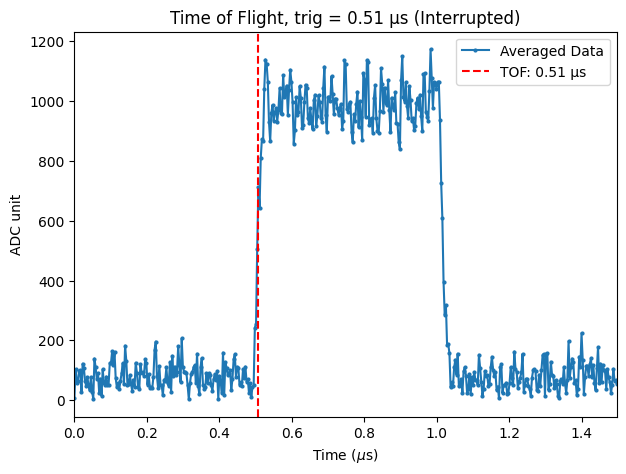

Data saved to D:\Labber_Data\Jay\test\2026\03\Data_0319\s001_tof_Q1_001


In [3]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_freq_ge": 6862,
        "ro_length": 1.5,
        "res_length": 0.5,
        "res_gain_ge": 1,
        "res_ch": 0,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(100)
tof.saveLabber(qubit)


In [4]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

{'Fres(GHz)': np.float64(6.8875),
 'Qi': -11738,
 'Ql': 154,
 'absQc': 152,
 'κ(MHz)': np.float64(44.72)}


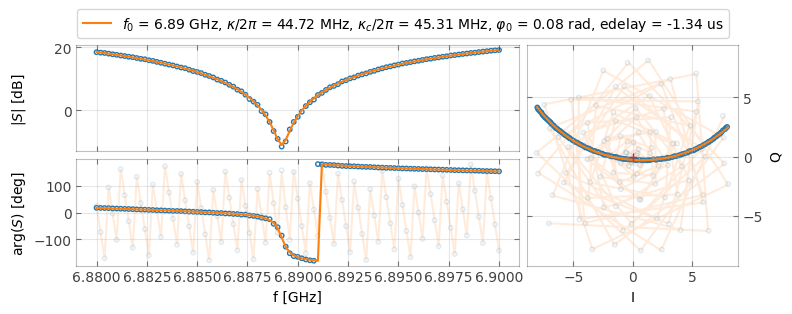

In [120]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10 # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.5, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=10, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [14]:
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0316\s002_onetone_ge_Q4_002


## OneTone PunchOut

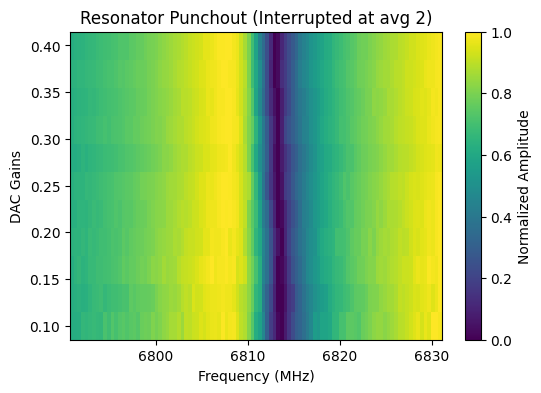

Experiment interrupted at 2 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0311\s002b_res_ge_punchout_Q3_003


In [281]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]
STEPS_freq = 101

START_gain = 0.1
STOP_gain = 0.4
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
    ]
)
punchout = Punchout(soc, soccfg, run_cfg)
punchout.run(py_avg=50, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 23 averages. Fit is based on partial data.


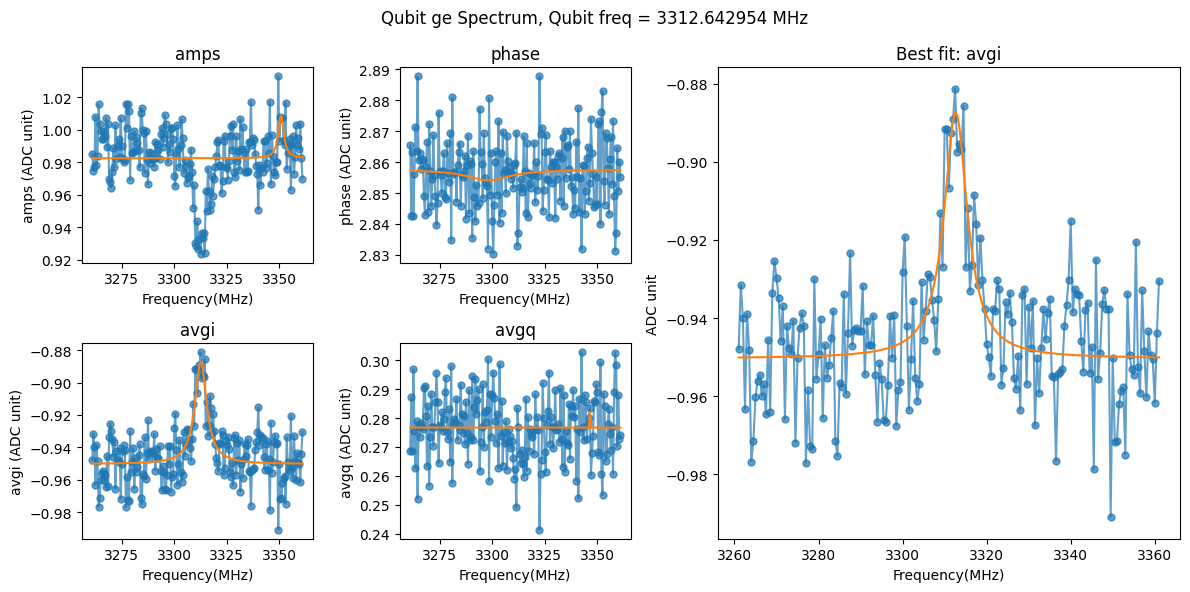

In [121]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = 3311
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", 5),
        ("relax_delay", 1),
        ("nqz_qb", 1),


    ]
)

spectrum_ge = QubitSpec(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(500)
config_all.update("qb.qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb.qb_mixer", f_ge, q_index=qubit)


In [5]:
spectrum_ge.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s003_qubit_spec_ge_Q3_001


## Time Rabi ge

Experiment interrupted at 16 averages. Fit is based on partial data.


(np.float64(0.05761112301473169), np.float64(0.037695581286774464))

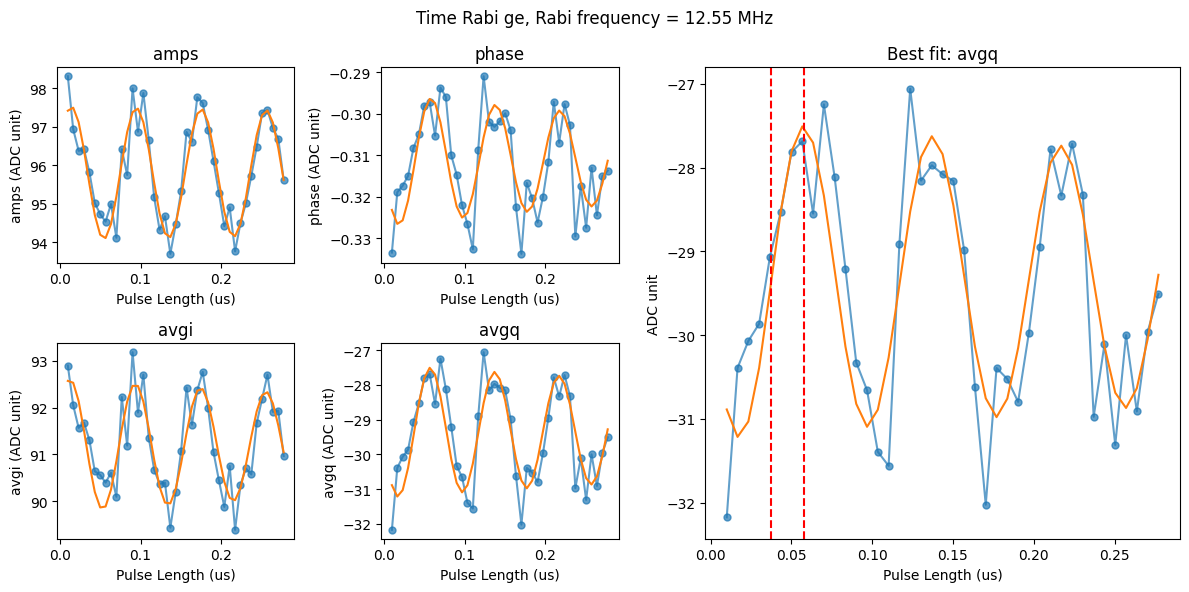

In [8]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi



config_all.update("qb.sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.4),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 41)
    ]
)

Trabi = TimeRabi(soc, soccfg, run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 82 averages. Fit is based on partial data.


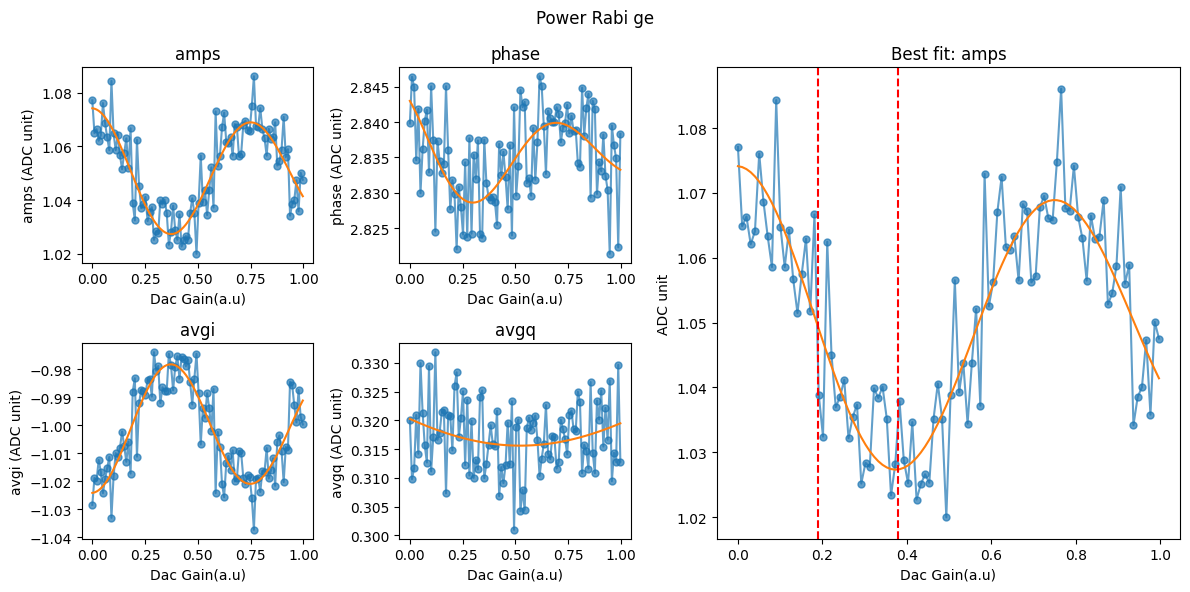

In [127]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ge", 0.05, q_index=qubit)
config_all.update("qb.nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),

    ]
)

prabi = PowerRabi(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi.run(300)
config_all.update("qb.pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ge", pi2_gain, q_index=qubit)

In [7]:
prabi.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s005_power_rabi_ge_Q3_001


## Amplified Amplitude Error (AAE)

Scan interrupted at average: 17


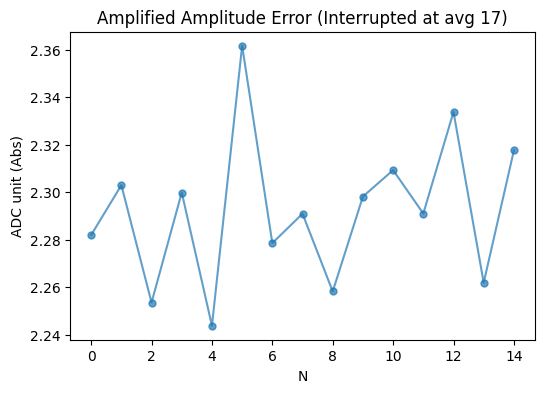

In [195]:
from qick_workspace.newscrip.s005a_AAE import AAE

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("AAE", "pi2"),

    ]
)

aae = AAE(soc, soccfg, run_cfg)
aae.run(100, iteration_count=15)

## Ramsey ge

Experiment interrupted at 90 averages. Fit is based on partial data.


(array([ 2.05541638e-02,  1.99214425e+00, -1.11577222e+02,  1.01589723e+01,
        -1.01173417e+00]),
 array([2.14986583e-03, 6.52837216e-03, 6.28325571e+00, 4.03475229e+00,
        6.28352114e-04]))

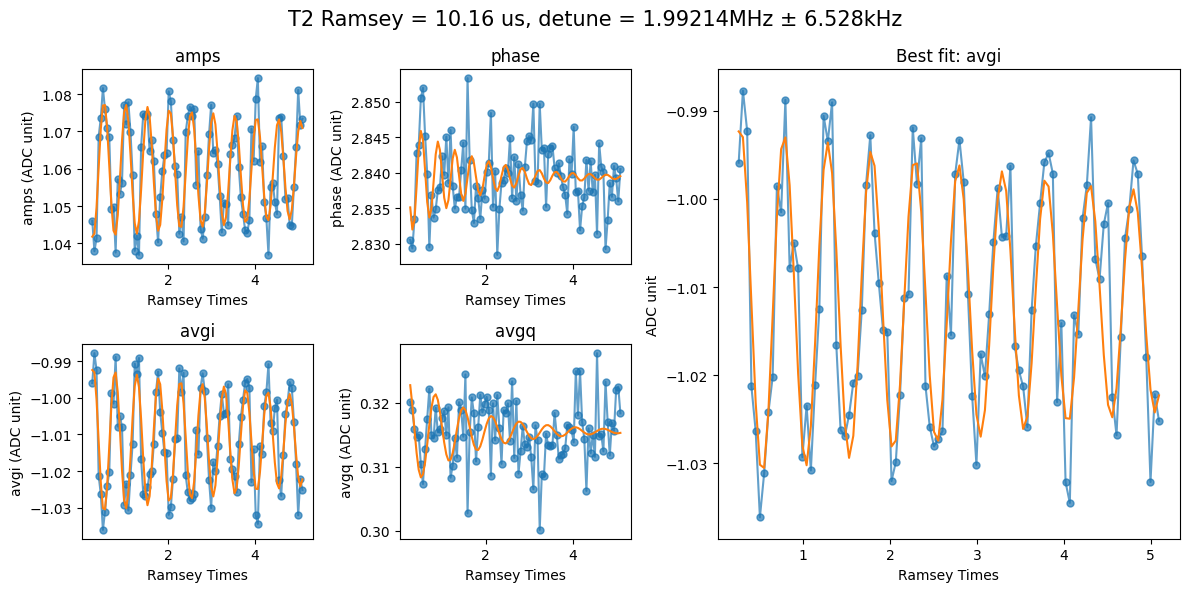

In [126]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(500)


In [125]:
config_all.update("qb.qb_freq_ge", t2r.correct_detune(), qubit)

over detune 0.68688MHz


In [10]:
t2r.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s006_Ramsey_ge_Q3_001


## Spin Echo ge

Experiment interrupted at 64 averages. Fit is based on partial data.


(array([1.68800401, 0.02171054, 3.8064231 ]),
 array([1.50465604e-03, 7.31978863e-03, 2.00710231e+00]))

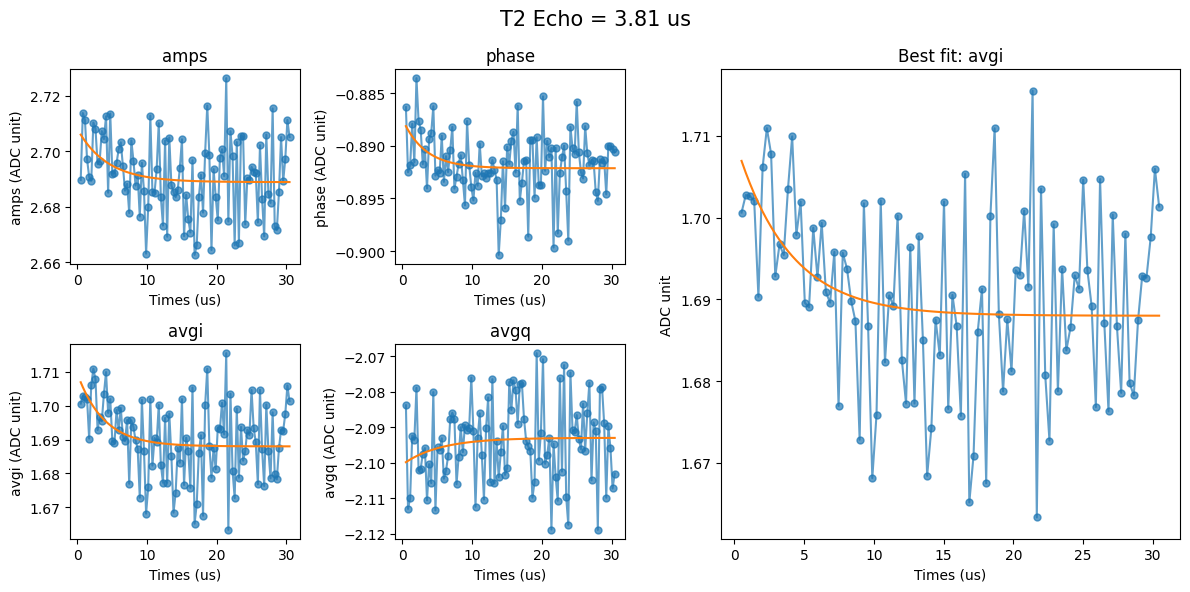

In [17]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME =30  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.0),

    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(500)

In [242]:
t2e.saveLabber(qubit,config_all=config_all, title="10mK")

Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0310\s007_SpinEcho_ge_Q3_10mK_001


## T1 ge

Experiment interrupted at 10 averages. Fit is based on partial data.


(array([ 1.41343648, -0.12316378, 26.10017698]),
 array([0.00694595, 0.01048442, 5.8237335 ]))

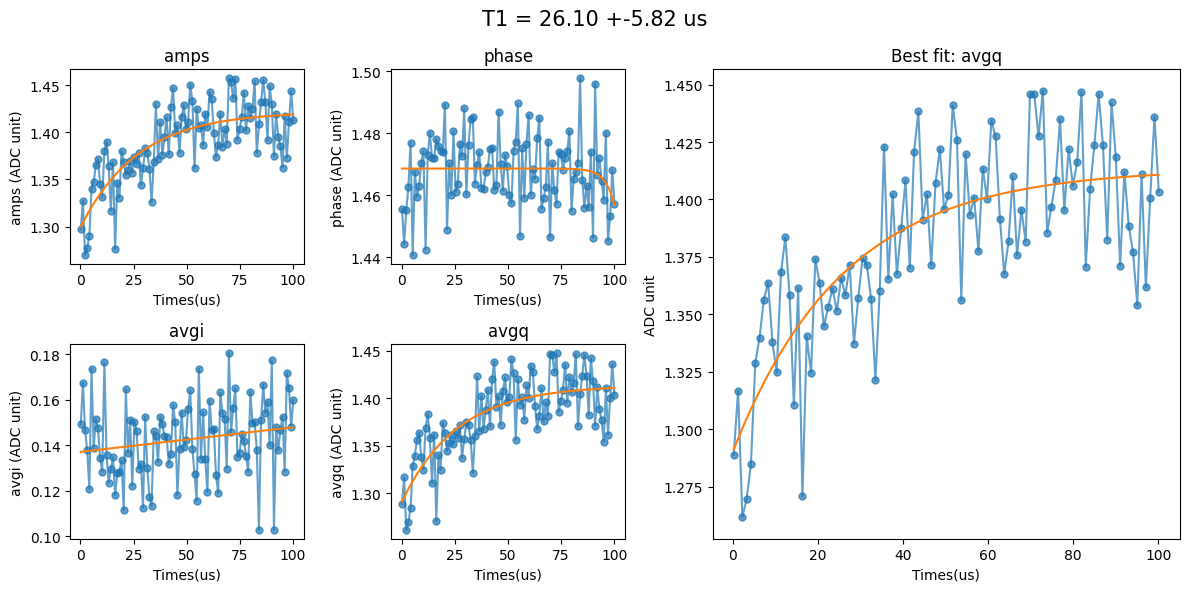

In [111]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        # ("cooling", False),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(300)

In [268]:
t1.saveLabber(qubit, config_all=config_all, title='10mK')

Data saved to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0311\s008_T1_ge_Q2_10mK_001


## Single Shot

  0%|          | 0/5000 [00:00<?, ?it/s]

Attempted to init fitparam 3 to 0.0, which is out of bounds 0 to 76. Instead init to 38.0
Attempted to init fitparam 3 to 0.0, which is out of bounds 0 to 82. Instead init to 41.0


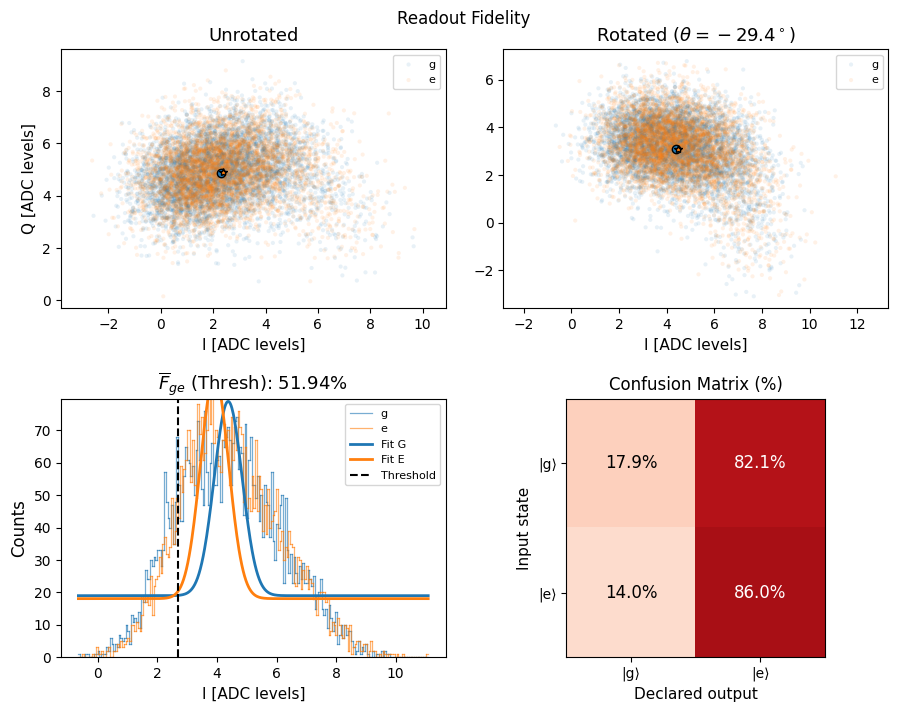

Theta: -29.40 deg
Threshold Fidelity: 51.940%
Confusion Matrix (%):
 [[17.86 82.14]
 [13.98 86.02]]


[[np.float64(0.5194)],
 [np.float64(2.6956220278576803)],
 np.float64(-29.399280734670818),
 [array([59.94226224,  4.37740253,  0.46973745, 18.98988126]),
  array([69.05927287,  3.92079472,  0.46973745, 18.07576298])],
 [array([[ 3.96072065e+01,  2.85638821e-08, -1.82800458e-01,
          -1.63235676e+00],
         [ 2.85638821e-08,  3.14856431e-03, -2.26693656e-10,
           1.98184580e-10],
         [-1.82800458e-01, -2.26693656e-10,  3.43209769e-03,
          -2.55839221e-02],
         [-1.63235676e+00,  1.98184580e-10, -2.55839221e-02,
           2.30850107e+00]]),
  array([[ 3.77715056e+01,  1.99125731e-08, -1.51313784e-01,
          -1.55670089e+00],
         [ 1.99125731e-08,  2.26216830e-03, -1.37902202e-10,
           1.01049054e-10],
         [-1.51313784e-01, -1.37902202e-10,  2.46588026e-03,
          -2.11771903e-02],
         [-1.55670089e+00,  1.01049054e-10, -2.11771903e-02,
           2.20150749e+00]])]]

In [201]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 1
run_cfg["res_gain_ge"] = 0.9

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=True)

# EF State

## Resonator OneTone ef

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8888),
 'Qi': -12178,
 'Ql': -172,
 'absQc': -174,
 'κ(MHz)': np.float64(-40.06)}


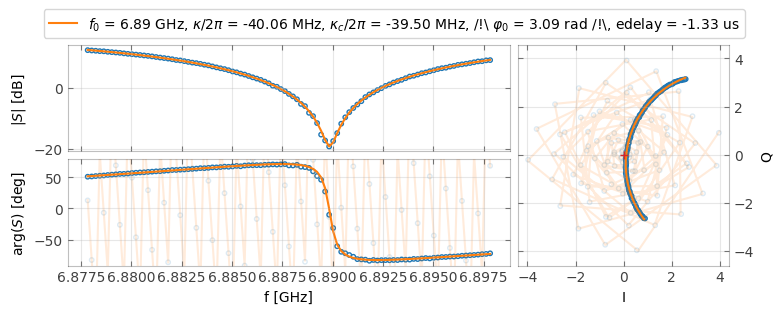

In [186]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.5, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 100),
    ]
)

onetone_ef = ResonatorSpec_ef(soc, soccfg, run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 17 averages. Fit is based on partial data.


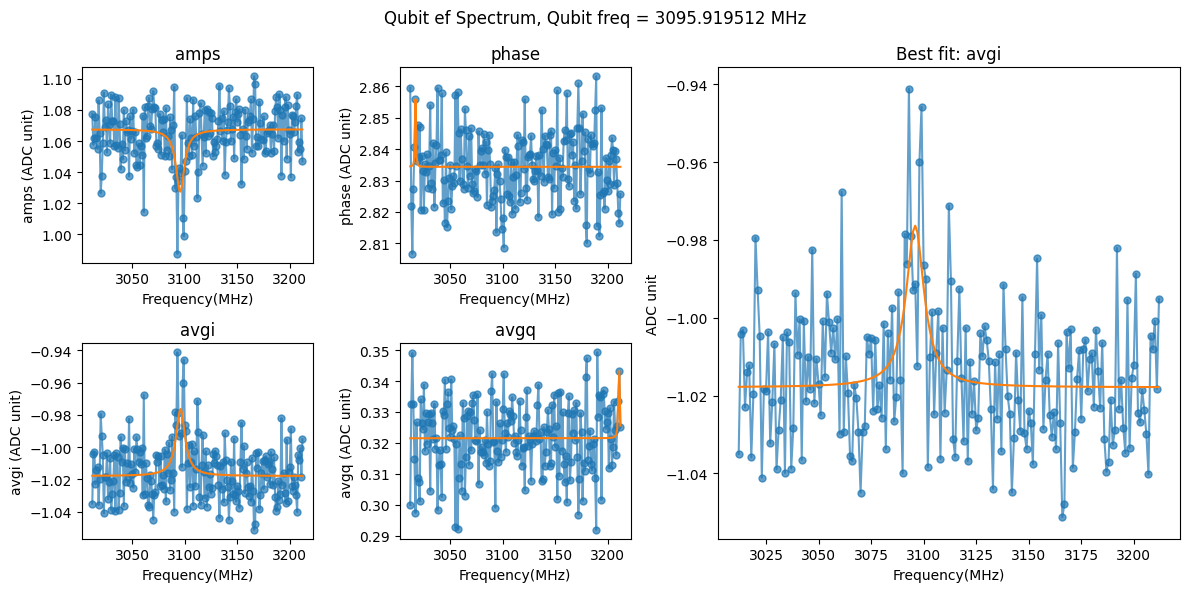

In [128]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center = config_all.get_qubit(qubit)["qb_freq_ge"]-200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201
config_all.update('ch.qb_ch_ef', 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.5),
        ("qb_flat_top_length_ef", 1),
        ("relax_delay", 50),
        ('ge_ref',True)

    ]
)

spectrum_ef = QubitSpec_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(500)
config_all.update("qb.qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb.qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

In [129]:
spectrum_ef.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s010_qubit_spec_ef_Q4_001


## Power Rabi ef

Experiment interrupted at 39 averages. Fit is based on partial data.


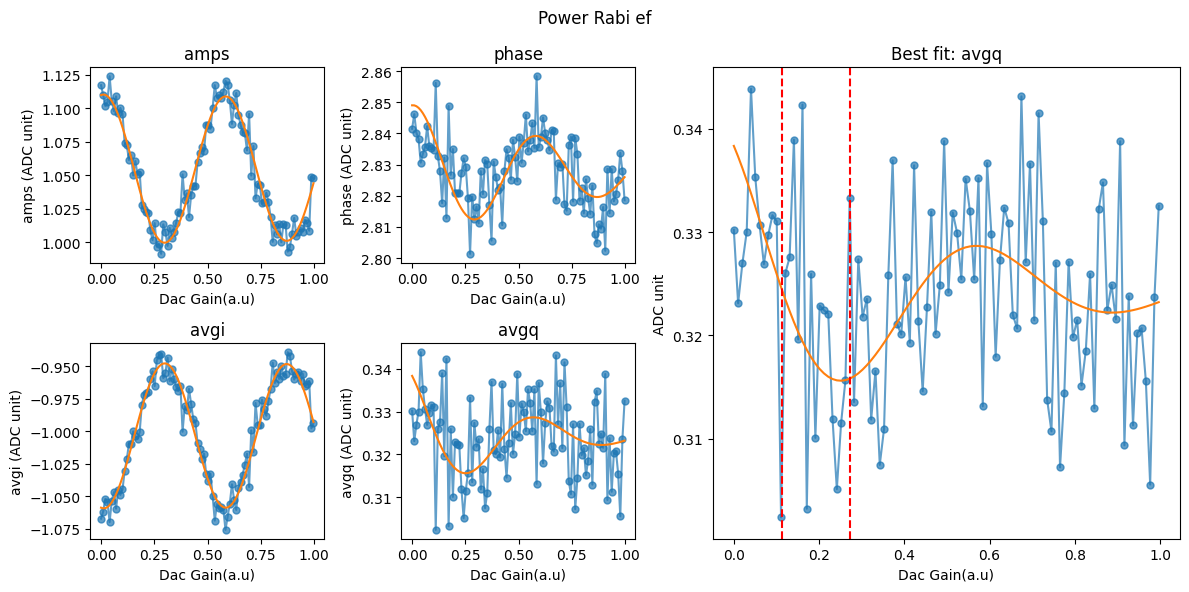

In [131]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.05, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ('ge_ref',True),

    ]
)

prabi_ef = PowerRabi_ef(soc, soccfg, run_cfg)
pi_gain_ef, pi2_gain_ef = prabi_ef.run(500)
config_all.update("qb.pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("qb.pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

[Temp] A_meas=0.0260  A_ref=0.0559  ratio=2.1471
[Temp] Estimated temperature: 208.02 mK


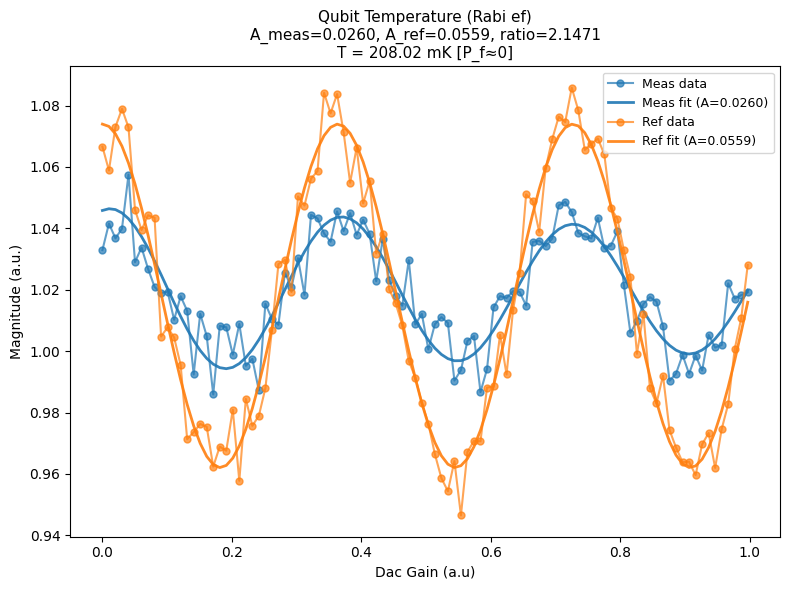

np.float64(0.20801737435055145)

In [135]:
from qick_workspace.newscrip.s013_qubit_temp import QubitTemperatureEf
START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.08, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ('ge_ref',True),
        ("qb_ch_ef", 0),

    ]
)
rabi_temp= QubitTemperatureEf(soc, soccfg, run_cfg)
rabi_temp.run(60)

In [136]:
rabi_temp.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s013b_qubit_temp_ef_Q4_001


## Ramsey ef

Experiment interrupted at 34 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s012_Ramsey_ef_Q4_001


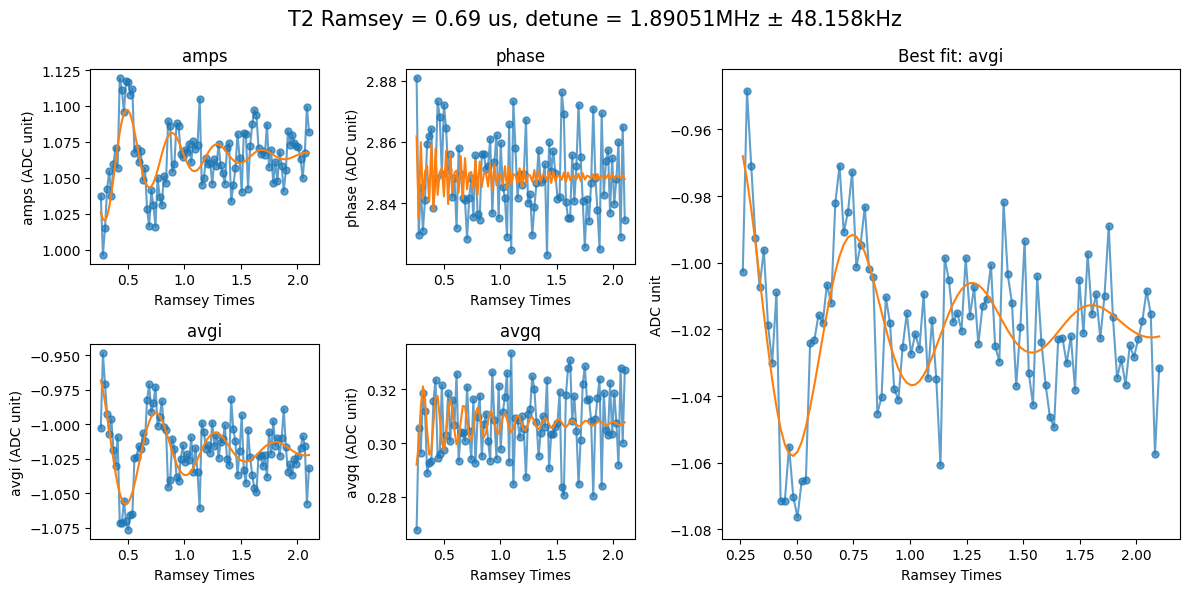

In [132]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ('ge_ref', True),
        ('ro_length', 2)
    ]
)

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [133]:
config_all.update("qb.qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune -0.10949MHz


## T1 ef

In [ ]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 50  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        ("cooling", False),
    ]
)

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50)
# t1_ef.saveLabber(qubit, yoko_value=yoko_value)

## Single Shot gef

In [ ]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 0.4
run_cfg["res_gain_ge"] = 0.17341
run_cfg["res_freq_ge"] = 5352.28064
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True, fit=False)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

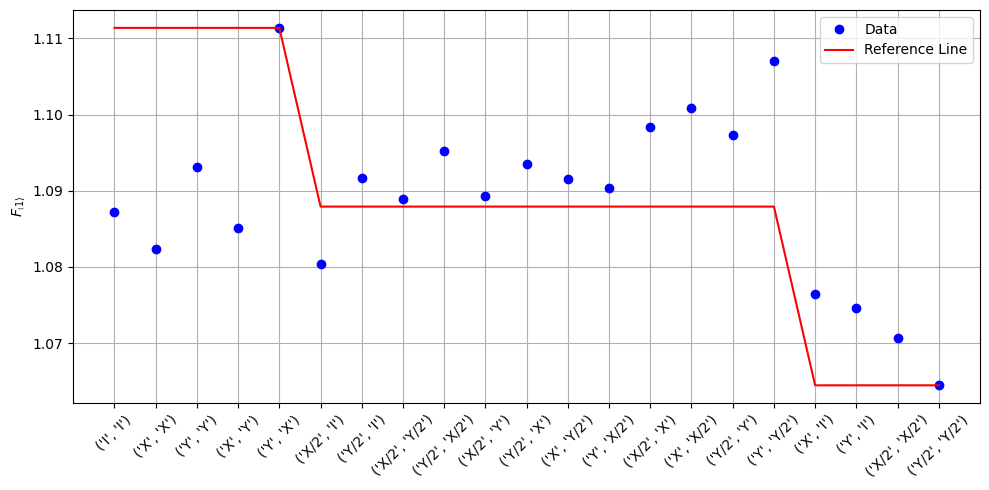

In [179]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(100)
allxy.plot()

# State Tomography

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (0.5468222005208333-0.9649803385416663j), IQ Excited: (0.5104021484375-0.9420525390624997j)


Tomography (x180):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=0.3231, <Y>=0.5949, <Z>=-1.0000
Purity: 1.00000


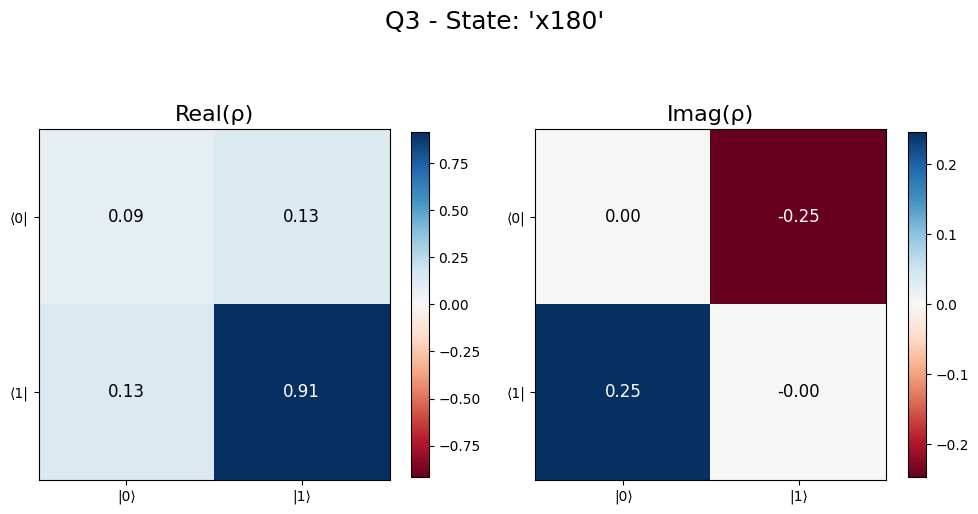

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s016_state_tomography.py:216: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


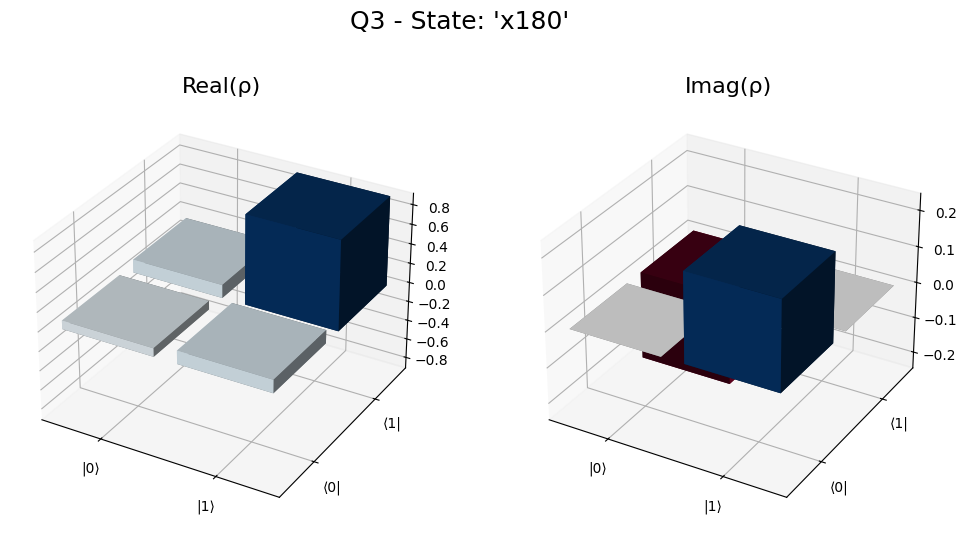

(<Figure size 1200x600 with 2 Axes>, None)

In [180]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

pyavg = 100

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

In [ ]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)

py_avg = 1
max_circuit_depth = 50
delta_clifford = 5
number_sample = 10

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)

## Interleaved RB

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)